In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# 기상청 데이터 로드 (학습용)
kma_df = pd.read_csv('KMA_weather.csv', encoding='cp949')
print("KMA 데이터 shape:", kma_df.shape)
print("\n컬럼명:")
print(kma_df.columns.tolist())
print("\n첫 5줄:")
kma_df.head()

KMA 데이터 shape: (4608, 38)

컬럼명:
['지점', '지점명', '일시', '기온(°C)', '기온 QC플래그', '강수량(mm)', '강수량 QC플래그', '풍속(m/s)', '풍속 QC플래그', '풍향(16방위)', '풍향 QC플래그', '습도(%)', '습도 QC플래그', '증기압(hPa)', '이슬점온도(°C)', '현지기압(hPa)', '현지기압 QC플래그', '해면기압(hPa)', '해면기압 QC플래그', '일조(hr)', '일조 QC플래그', '일사(MJ/m2)', '일사 QC플래그', '적설(cm)', '3시간신적설(cm)', '전운량(10분위)', '중하층운량(10분위)', '운형(운형약어)', '최저운고(100m )', '시정(10m)', '지면상태(지면상태코드)', '현상번호(국내식)', '지면온도(°C)', '지면온도 QC플래그', '5cm 지중온도(°C)', '10cm 지중온도(°C)', '20cm 지중온도(°C)', '30cm 지중온도(°C)']

첫 5줄:


,지점,지점명,일시,기온(°C),기온 QC플래그,강수량(mm),강수량 QC플래그,풍속(m/s),풍속 QC플래그,풍향(16방위),...,최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),지면온도 QC플래그,5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
0,156,광주,2025-09-26 01:00,22.1,NaN,NaN,NaN,1.0,NaN,360,...,6.0,4731,NaN,NaN,23.6,NaN,NaN,NaN,NaN,NaN
1,156,광주,2025-09-26 02:00,22.1,NaN,NaN,NaN,0.0,NaN,0,...,9.0,4998,NaN,NaN,23.7,NaN,NaN,NaN,NaN,NaN
2,156,광주,2025-09-26 03:00,22.2,NaN,0.0,NaN,0.7,NaN,200,...,10.0,766,NaN,2.0,23.7,NaN,NaN,NaN,NaN,NaN
3,156,광주,2025-09-26 04:00,22.0,NaN,0.0,NaN,0.0,NaN,0,...,10.0,3235,NaN,2.0,23.7,NaN,NaN,NaN,NaN,NaN
4,156,광주,2025-09-26 05:00,22.0,NaN,NaN,9.0,0.0,NaN,0,...,10.0,2921,NaN,NaN,23.6,NaN,NaN,NaN,NaN,NaN


In [6]:
# IoT 센서 데이터 로드 (실시간 예측용)
iot_df = pd.read_csv('total_iot_sensor.csv')
print("\nIoT 데이터 shape:", iot_df.shape)
print("\n컬럼명:")
print(iot_df.columns.tolist())
print("\n첫 5줄:")
iot_df.head()


IoT 데이터 shape: (239395, 14)

컬럼명:
['seq', 'device_id', 'tx_type', 'battery', 'wind_direction', 'temperature', 'humidity', 'wind_speed', 'gust_speed', 'rainfall_accumulation', 'uv_index', 'light_intensity', 'pressure', 'create_at']

첫 5줄:


,seq,device_id,tx_type,battery,wind_direction,temperature,humidity,wind_speed,gust_speed,rainfall_accumulation,uv_index,light_intensity,pressure,create_at
0,239421,3A,24,10000010,54,14.8,92,0.00,0.00,503.682,74,9773.0,1004.68,2026-04-06 13:14:39
1,239420,3A,24,10000010,54,14.8,92,0.38,0.51,503.682,67,8904.0,1004.75,2026-04-06 13:13:35
2,239419,3A,24,10000010,54,14.9,92,0.38,0.51,503.682,64,8488.0,1004.89,2026-04-06 13:12:31
3,239418,3A,24,10000010,54,14.9,93,0.19,0.51,503.682,54,7263.0,1004.72,2026-04-06 13:11:27
4,239417,3A,24,10000010,54,14.9,93,0.06,0.00,503.682,57,7600.0,1004.86,2026-04-06 13:10:23


In [8]:
# KMA 데이터 전처리
# 일사(MJ/m2)가 타겟, 기상 변수들이 특성

# 타겟: 일사(MJ/m2)
target_col = '일사(MJ/m2)'

# 특성으로 사용할 컬럼들
feature_cols = ['기온(°C)', '습도(%)', '해면기압(hPa)', '강수량(mm)', 
                '풍속(m/s)', '전운량(10분위)', '지면온도(°C)']

# 유효한 데이터만 선택
kma_clean = kma_df[[target_col] + feature_cols].copy()

# 결측치 제거
kma_clean = kma_clean.dropna()

print(f"학습용 KMA 데이터: {kma_clean.shape}")
print(f"일사량 통계:")
print(kma_clean[target_col].describe())

학습용 KMA 데이터: (149, 8)
일사량 통계:
count    149.000000
mean       0.412013
std        0.438476
min        0.000000
25%        0.100000
50%        0.290000
75%        0.580000
max        2.170000
Name: 일사(MJ/m2), dtype: float64


In [9]:
# 데이터 분할 및 정규화
X = kma_clean[feature_cols]
y = kma_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 특성 정규화 (스케일러 저장 - 나중에 IoT 데이터 예측시 사용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"학습 데이터: {X_train_scaled.shape}")
print(f"테스트 데이터: {X_test_scaled.shape}")

학습 데이터: (119, 7)
테스트 데이터: (30, 7)


In [36]:
# 모델 학습 (낮시간 데이터만 + 전운량 포함)
# 일사량은 주간에만 의미있으므로, 강수량은 결측치가 많아서 제외

kma_df['일시'] = pd.to_datetime(kma_df['일시'])
kma_df['시간'] = kma_df['일시'].dt.hour

# 낮시간(6~18시) + 일사량 > 0인 데이터만 선택
kma_daytime = kma_df[(kma_df['시간'] >= 6) & (kma_df['시간'] <= 18) & (kma_df['일사(MJ/m2)'] > 0)].copy()

print(f"전체 KMA 데이터: {len(kma_df):,}개")
print(f"낮시간 일사량 데이터: {len(kma_daytime):,}개")

# IoT에서 사용할 수 없는 특성: 강수량 (결측치 93%) → 제외
feature_cols = ['기온(°C)', '습도(%)', '해면기압(hPa)', '풍속(m/s)', '전운량(10분위)']

kma_clean = kma_daytime[feature_cols + [target_col]].dropna()

print(f"최종 학습 데이터: {len(kma_clean):,}개")

X = kma_clean[feature_cols]
y = kma_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Forest (과적합 방지)
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)

# 모델 성능 평가
train_score = model.score(X_train_scaled, y_train)
test_score = model.score(X_test_scaled, y_test)

print(f"\n학습 데이터 R² 점수: {train_score:.4f}")
print(f"테스트 데이터 R² 점수: {test_score:.4f}")

if test_score > 0.5:
    print("\n✓ 모델 성능 양호 - 사용 가능")
elif test_score > 0:
    print("\n△ 모델 성능 개선 - 사용 가능")
else:
    print("\n✗ 모델 성능 불량")

# 특성 중요도
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n특성 중요도:")
print(feature_importance)

전체 KMA 데이터: 4,608개
낮시간 일사량 데이터: 2,130개
최종 학습 데이터: 2,130개

학습 데이터 R² 점수: 0.5160
테스트 데이터 R² 점수: 0.5095

✓ 모델 성능 양호 - 사용 가능

특성 중요도:
     feature  importance
1      습도(%)    0.636651
0     기온(°C)    0.216977
4  전운량(10분위)    0.095736
2  해면기압(hPa)    0.026615
3    풍속(m/s)    0.024020


In [37]:
# IoT 데이터로 일사량 예측
# IoT 컬럼과 KMA 컬럼 매핑
iot_feature_mapping = {
    'temperature': '기온(°C)',
    'humidity': '습도(%)',
    'pressure': '해면기압(hPa)',
    'wind_speed': '풍속(m/s)'
}

# IoT 데이터 중 필요한 컬럼만 추출
iot_clean = iot_df[list(iot_feature_mapping.keys())].copy()

# 전운량은 IoT에 없으므로 기본값 설정 (중간값)
iot_clean['전운량(10분위)'] = 5

# 컬럼명 변경
iot_clean = iot_clean.rename(columns=iot_feature_mapping)

# 필요한 순서대로 정렬
iot_for_pred = iot_clean[feature_cols]

print("IoT 예측용 데이터 shape:", iot_for_pred.shape)
print("\nIoT 데이터 일부:")
print(iot_for_pred.head())

IoT 예측용 데이터 shape: (239395, 5)

IoT 데이터 일부:
   기온(°C)  습도(%)  해면기압(hPa)  풍속(m/s)  전운량(10분위)
0    14.8     92    1004.68     0.00          5
1    14.8     92    1004.75     0.38          5
2    14.9     92    1004.89     0.38          5
3    14.9     93    1004.72     0.19          5
4    14.9     93    1004.86     0.06          5


In [38]:
# 예측 수행
iot_scaled = scaler.transform(iot_for_pred)
iot_predictions = model.predict(iot_scaled)

# 결과 통합
iot_with_pred = iot_df.copy()
iot_with_pred['predicted_insolation'] = iot_predictions

# 예측값 범위 제한 (음수 제거)
iot_with_pred['predicted_insolation'] = iot_with_pred['predicted_insolation'].clip(lower=0)

print("예측 결과 (처음 10줄):")
print(iot_with_pred[['create_at', 'temperature', 'humidity', 'predicted_insolation']].head(10))

print(f"\n예측된 일사량 통계:")
print(iot_with_pred['predicted_insolation'].describe())

예측 결과 (처음 10줄):
             create_at  temperature  humidity  predicted_insolation
0  2026-04-06 13:14:39         14.8        92              0.276122
1  2026-04-06 13:13:35         14.8        92              0.274208
2  2026-04-06 13:12:31         14.9        92              0.274208
3  2026-04-06 13:11:27         14.9        93              0.271973
4  2026-04-06 13:10:23         14.9        93              0.275656
5  2026-04-06 13:09:19         14.9        93              0.271973
6  2026-04-06 13:08:15         14.9        93              0.271973
7  2026-04-06 13:07:11         14.9        93              0.271973
8  2026-04-06 13:06:07         14.8        93              0.271973
9  2026-04-06 13:05:03         14.8        93              0.275656

예측된 일사량 통계:
count    239395.000000
mean          0.731853
std           0.552342
min           0.156427
25%           0.244245
50%           0.575642
75%           1.133639
max           2.432323
Name: predicted_insolation, dtype: floa

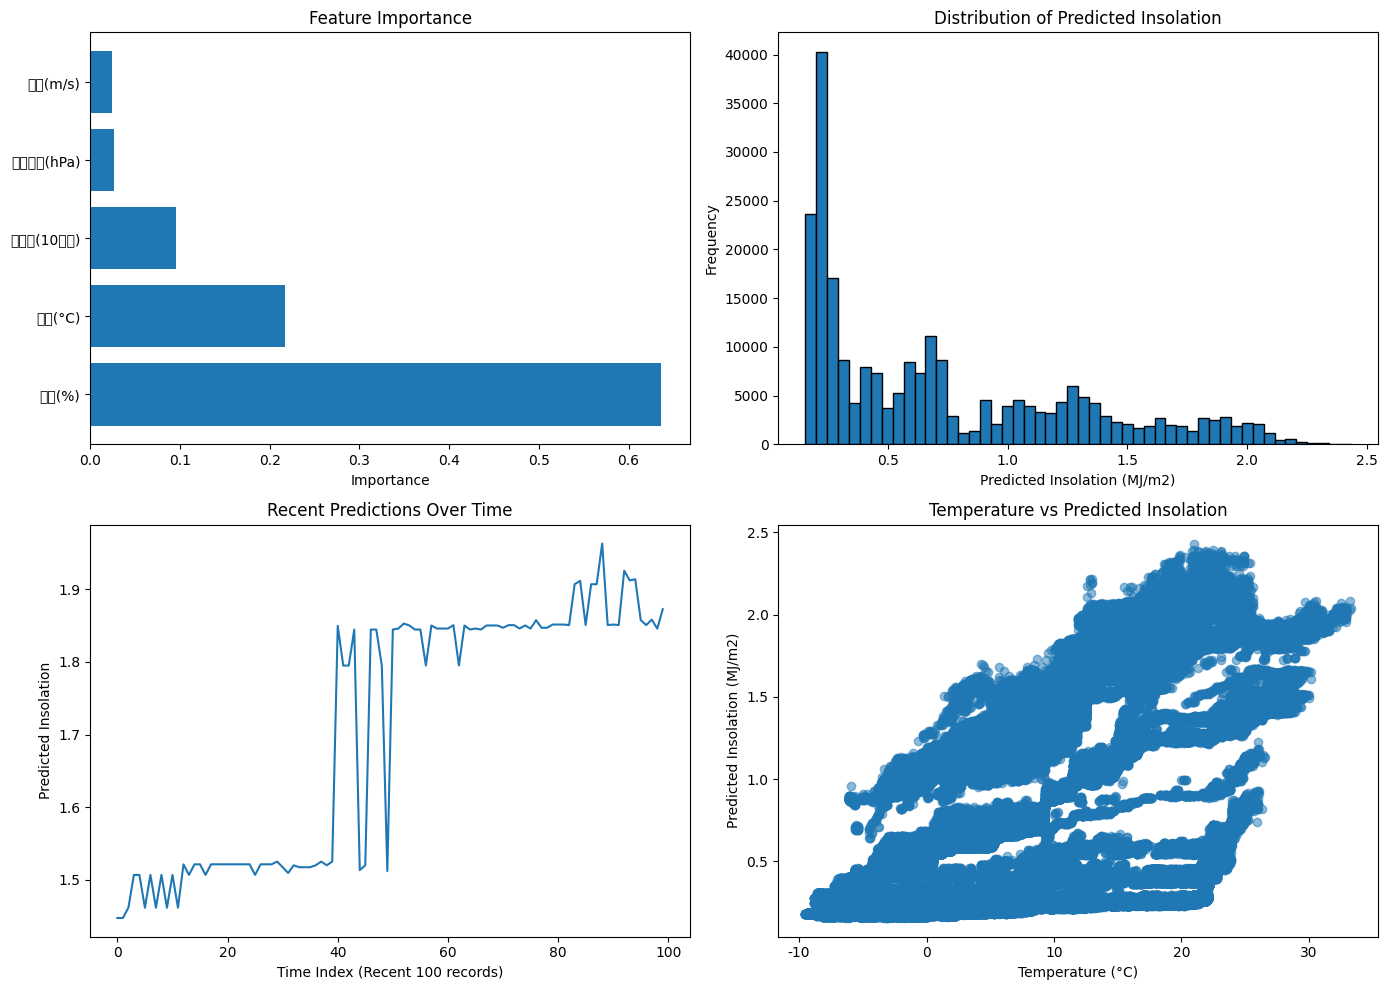

시각화 저장: insolation_prediction.png


In [39]:
# 결과 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 특성 중요도
axes[0, 0].barh(feature_importance['feature'], feature_importance['importance'])
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title('Feature Importance')

# 2. 예측값 분포
axes[0, 1].hist(iot_with_pred['predicted_insolation'], bins=50, edgecolor='black')
axes[0, 1].set_xlabel('Predicted Insolation (MJ/m2)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Predicted Insolation')

# 3. 시간대별 예측값 (최근 100개)
axes[1, 0].plot(iot_with_pred['predicted_insolation'].tail(100).reset_index(drop=True))
axes[1, 0].set_xlabel('Time Index (Recent 100 records)')
axes[1, 0].set_ylabel('Predicted Insolation')
axes[1, 0].set_title('Recent Predictions Over Time')

# 4. 온도 vs 예측된 일사량
axes[1, 1].scatter(iot_with_pred['temperature'], iot_with_pred['predicted_insolation'], alpha=0.5)
axes[1, 1].set_xlabel('Temperature (°C)')
axes[1, 1].set_ylabel('Predicted Insolation (MJ/m2)')
axes[1, 1].set_title('Temperature vs Predicted Insolation')

plt.tight_layout()
plt.savefig('insolation_prediction.png', dpi=100)
plt.show()

print("시각화 저장: insolation_prediction.png")

In [40]:
# 결과 저장
output_df = iot_with_pred[['create_at', 'device_id', 'temperature', 'humidity', 
                            'wind_speed', 'pressure', 'light_intensity', 
                            'predicted_insolation']].copy()

output_df.to_csv('iot_with_insolation_predictions.csv', index=False)

print("예측 결과 저장: iot_with_insolation_predictions.csv")
print(f"\n저장된 레코드: {len(output_df):,}개")
print(f"시간 범위: {output_df['create_at'].min()} ~ {output_df['create_at'].max()}")

예측 결과 저장: iot_with_insolation_predictions.csv

저장된 레코드: 239,395개
시간 범위: 2025-09-26 15:41:07 ~ 2026-04-06 13:14:39


In [41]:
# 모델과 전처리기 저장 (나중에 새로운 IoT 데이터 예측시 재사용)
import joblib

joblib.dump(model, 'insolation_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [25]:
print("✓ 모델 저장: insolation_model.pkl")
print("✓ 전처리기 저장: scaler.pkl")
print("\n=== 새로운 IoT 데이터로 예측하는 방법 ===\n")

# 실제 사용 예시

# 1단계: 저장된 모델과 스케일러 로드
model = joblib.load('insolation_model.pkl')
scaler = joblib.load('scaler.pkl')

# 2단계: 새로운 IoT 데이터 준비 (feature_cols과 같은 컬럼 구성)
new_iot_data = pd.DataFrame({
    '기온(°C)': [15.2, 16.5],
    '습도(%)': [85, 82],
    '해면기압(hPa)': [1013.5, 1013.2],
    '강수량(mm)': [0, 0],
    '풍속(m/s)': [2.3, 1.8],
    '전운량(10분위)': [5, 4],
    '지면온도(°C)': [15, 16]
})

# 3단계: 예측 수행
predictions = model.predict(scaler.transform(new_iot_data))
print(predictions)  # [예측된 일사량1, 예측된 일사량2, ...]

✓ 모델 저장: insolation_model.pkl
✓ 전처리기 저장: scaler.pkl

=== 새로운 IoT 데이터로 예측하는 방법 ===

[0.634775   0.57983333]
